# Salary Data Analysis and Prediction

This project explores salary data to identify patterns related to experience, education, and job level, and builds a Linear Regression model to predict salaries.

## 1. Import Libraries

In [1]:
import pandas as pd

## 2. Load and Explore the Dataset

In [2]:
df=pd.read_csv('SalaryData.csv')

In [3]:
df.head()


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0
374,44.0,Female,PhD,Senior Business Analyst,15.0,150000.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [6]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [7]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

## 3. Data Cleaning

In this section, missing values, data types, duplicate records, and potential salary errors are examined and handled.

In [8]:
df=df.dropna(subset=['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary']).copy()

In [9]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [10]:
df["Age"]=df["Age"].astype(int)

In [11]:
def gender(g):
    if g=="Male":
       return 0
    elif g=="Female":
        return 1

df["Gender"]=df["Gender"].apply(gender)


In [12]:
df["Education Level"].value_counts()

Education Level
Bachelor's    224
Master's       98
PhD            51
Name: count, dtype: int64

In [13]:
def edu(e):
    if e=="Bachelor's":
        return 0 
    elif e=="Master's":
        return 1
    elif e=="PhD":
        return 2

df["Education Level"]=df["Education Level"].apply(edu)

In [14]:
df["Years of Experience"]=df["Years of Experience"].astype(int)
df["Salary"]=df["Salary"].astype(int)

In [15]:
df["Job Title"].value_counts()

Job Title
Director of Marketing             12
Director of Operations            11
Senior Business Analyst           10
Senior Marketing Manager           9
Senior Marketing Analyst           9
                                  ..
Junior Social Media Specialist     1
Junior Operations Coordinator      1
Senior HR Specialist               1
Director of HR                     1
Junior Financial Advisor           1
Name: count, Length: 174, dtype: int64

In [16]:
df["Job Title"].unique()

array(['Software Engineer', 'Data Analyst', 'Senior Manager',
       'Sales Associate', 'Director', 'Marketing Analyst',
       'Product Manager', 'Sales Manager', 'Marketing Coordinator',
       'Senior Scientist', 'Software Developer', 'HR Manager',
       'Financial Analyst', 'Project Manager', 'Customer Service Rep',
       'Operations Manager', 'Marketing Manager', 'Senior Engineer',
       'Data Entry Clerk', 'Sales Director', 'Business Analyst',
       'VP of Operations', 'IT Support', 'Recruiter', 'Financial Manager',
       'Social Media Specialist', 'Software Manager', 'Junior Developer',
       'Senior Consultant', 'Product Designer', 'CEO', 'Accountant',
       'Data Scientist', 'Marketing Specialist', 'Technical Writer',
       'HR Generalist', 'Project Engineer', 'Customer Success Rep',
       'Sales Executive', 'UX Designer', 'Operations Director',
       'Network Engineer', 'Administrative Assistant',
       'Strategy Consultant', 'Copywriter', 'Account Manager',
      

In [17]:
df["Job Title"].nunique()

174

In [18]:
df.duplicated().sum()

np.int64(49)

In [19]:
df[df.duplicated(keep=False)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
140,28,0,0,Junior Business Analyst,2,40000
195,28,0,0,Junior Business Analyst,2,40000
209,30,1,0,Junior Marketing Coordinator,2,40000
210,38,0,1,Senior IT Consultant,9,110000
211,45,1,2,Senior Product Designer,15,150000
...,...,...,...,...,...,...
369,33,0,0,Junior Business Analyst,4,60000
370,35,1,0,Senior Marketing Analyst,8,85000
372,29,1,0,Junior Project Manager,2,40000
373,34,0,0,Senior Operations Coordinator,7,90000


In [20]:
df.describe()

,Age,Gender,Education Level,Years of Experience,Salary
count,373.000000,373.000000,373.000000,373.000000,373.000000
mean,37.431635,0.479893,0.536193,10.013405,100577.345845
std,7.069073,0.500267,0.723569,6.580546,48240.013482
min,23.000000,0.000000,0.000000,0.000000,350.000000
25%,31.000000,0.000000,0.000000,4.000000,55000.000000
50%,36.000000,0.000000,0.000000,9.000000,95000.000000
75%,44.000000,1.000000,1.000000,15.000000,140000.000000
max,53.000000,1.000000,2.000000,25.000000,250000.000000


In [21]:
df[df["Salary"]<10000]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
259,29,0,0,Junior Business Operations Analyst,1,350


In [22]:
df[df["Job Title"] == "Junior Business Operations Analyst"]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
218,29,0,0,Junior Business Operations Analyst,1,35000
259,29,0,0,Junior Business Operations Analyst,1,350


In [23]:
df.loc[df["Salary"]==350 , "Salary"]=35000

In [24]:
df["Salary"].min()

np.int64(30000)

## 4. Feature Engineering

A new feature called `Job Level` was created from the `Job Title` column to group job titles into broader categories: Junior Level, Senior Level, Management, and Other.

In [25]:
df["Job Title"].str.contains("Senior").sum()

np.int64(152)

In [26]:
df["Job Title"].str.contains("Junior").sum()

np.int64(90)

In [27]:
df[~(df["Job Title"].str.contains("Junior")|df["Job Title"].str.contains("Senior"))]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32,0,0,Software Engineer,5,90000
1,28,1,1,Data Analyst,3,65000
3,36,1,0,Sales Associate,7,60000
4,52,0,1,Director,20,200000
5,29,0,0,Marketing Analyst,2,55000
...,...,...,...,...,...,...
347,45,0,1,Director of Engineering,19,180000
353,48,0,1,Director of Marketing,21,180000
359,47,0,1,Director of Operations,19,170000
365,43,0,1,Director of Marketing,18,170000


In [28]:
def jobtitle(j):
    if "Manager" in j or "Director" in j:
        return "Management"
    elif "Junior" in j:
        return "Junior Level"
    elif "Senior" in j:
        return "Senior Level"
    else:
        return "Other"

df["Job Level"]=df["Job Title"].apply(jobtitle)
    

In [29]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Job Level
0,32,0,0,Software Engineer,5,90000,Other
1,28,1,1,Data Analyst,3,65000,Other
2,45,0,2,Senior Manager,15,150000,Management
3,36,1,0,Sales Associate,7,60000,Other
4,52,0,1,Director,20,200000,Management
...,...,...,...,...,...,...,...
370,35,1,0,Senior Marketing Analyst,8,85000,Senior Level
371,43,0,1,Director of Operations,19,170000,Management
372,29,1,0,Junior Project Manager,2,40000,Management
373,34,0,0,Senior Operations Coordinator,7,90000,Senior Level


In [30]:
df["Job Level"].value_counts()

Job Level
Management      138
Senior Level    102
Junior Level     72
Other            61
Name: count, dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  373 non-null    int64 
 1   Gender               373 non-null    int64 
 2   Education Level      373 non-null    int64 
 3   Job Title            373 non-null    object
 4   Years of Experience  373 non-null    int64 
 5   Salary               373 non-null    int64 
 6   Job Level            373 non-null    object
dtypes: int64(5), object(2)
memory usage: 23.3+ KB


In [32]:
df=df.reset_index(drop=True)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  373 non-null    int64 
 1   Gender               373 non-null    int64 
 2   Education Level      373 non-null    int64 
 3   Job Title            373 non-null    object
 4   Years of Experience  373 non-null    int64 
 5   Salary               373 non-null    int64 
 6   Job Level            373 non-null    object
dtypes: int64(5), object(2)
memory usage: 20.5+ KB


In [34]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
Job Level              0
dtype: int64

In [35]:
df.describe()

,Age,Gender,Education Level,Years of Experience,Salary
count,373.000000,373.000000,373.000000,373.000000,373.000000
mean,37.431635,0.479893,0.536193,10.013405,100670.241287
std,7.069073,0.500267,0.723569,6.580546,48079.583434
min,23.000000,0.000000,0.000000,0.000000,30000.000000
25%,31.000000,0.000000,0.000000,4.000000,55000.000000
50%,36.000000,0.000000,0.000000,9.000000,95000.000000
75%,44.000000,1.000000,1.000000,15.000000,140000.000000
max,53.000000,1.000000,2.000000,25.000000,250000.000000


In [36]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Job Level
0,32,0,0,Software Engineer,5,90000,Other
1,28,1,1,Data Analyst,3,65000,Other
2,45,0,2,Senior Manager,15,150000,Management
3,36,1,0,Sales Associate,7,60000,Other
4,52,0,1,Director,20,200000,Management
...,...,...,...,...,...,...,...
368,35,1,0,Senior Marketing Analyst,8,85000,Senior Level
369,43,0,1,Director of Operations,19,170000,Management
370,29,1,0,Junior Project Manager,2,40000,Management
371,34,0,0,Senior Operations Coordinator,7,90000,Senior Level


## 5. Exploratory Data Analysis and Visualization

In this section, salary patterns and relationships between key variables are explored using statistical analysis and visualizations.

In [37]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Salary Distribution')

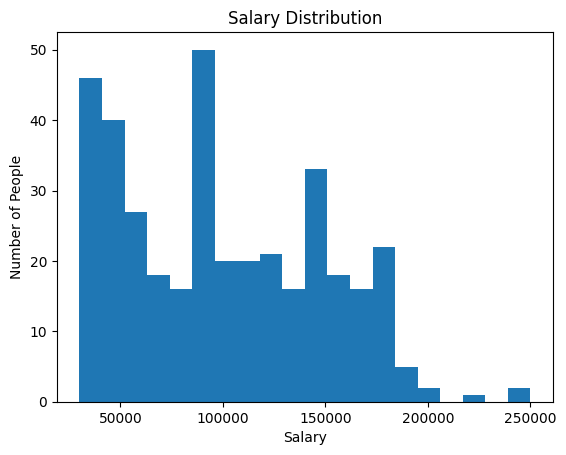

In [38]:
plt.hist(df["Salary"] , bins=20)
plt.xlabel("Salary")
plt.ylabel("Number of People")
plt.title("Salary Distribution")


Text(0.5, 1.0, 'Relationship Between Salary and Experience')

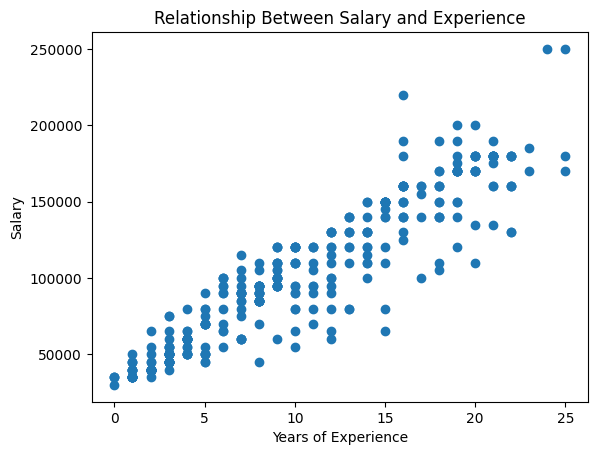

In [39]:
plt.scatter(df["Years of Experience"], df["Salary"])
plt.ylabel("Salary")
plt.xlabel("Years of Experience")
plt.title("Relationship Between Salary and Experience")

In [40]:
df["Years of Experience"].corr(df["Salary"])

np.float64(0.9310059589498264)

In [41]:
salary_by_level=df.groupby("Job Level")["Salary"].mean()

Text(0.5, 0, 'Level')

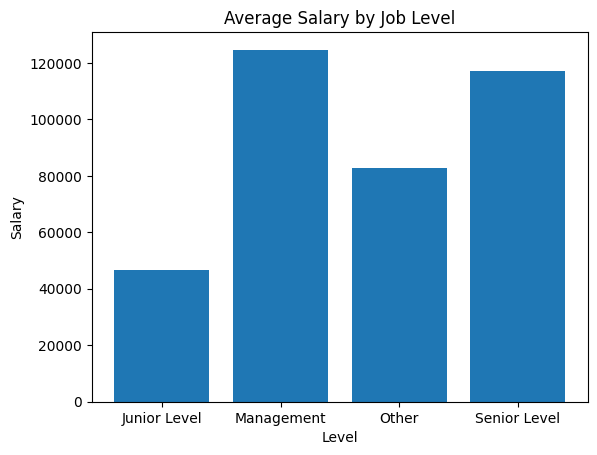

In [42]:
plt.bar(salary_by_level.index , salary_by_level.values)
plt.title("Average Salary by Job Level")
plt.ylabel("Salary")
plt.xlabel("Level")

In [43]:
Junior_Salary=df[df["Job Level"]=="Junior Level"]["Salary"]

In [44]:
Senior_Salary=df[df["Job Level"]=="Senior Level"]["Salary"]

In [45]:
Manager_Salary=df[df["Job Level"]=="Management"]["Salary"]

In [46]:
Other_Salary=df[df["Job Level"]=="Other"]["Salary"]

Text(0.5, 0, 'Job Level')

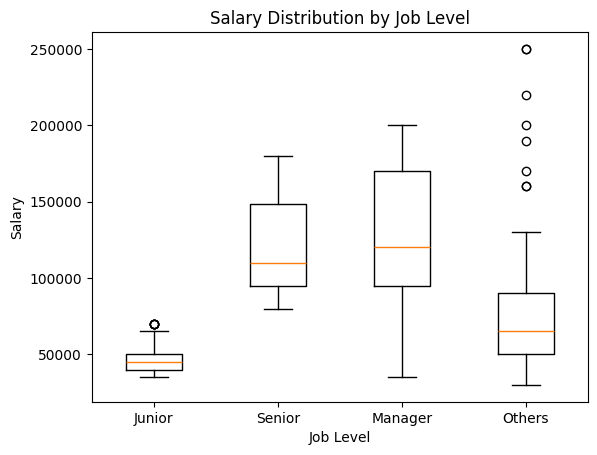

In [47]:
plt.boxplot([Junior_Salary , Senior_Salary, Manager_Salary , Other_Salary],tick_labels=["Junior" , "Senior" , "Manager","Others"])
plt.title("Salary Distribution by Job Level")
plt.ylabel("Salary")
plt.xlabel("Job Level")

In [48]:
df[(df["Job Level"]=="Other")&(df["Salary"] > 150000)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Job Level
21,47,0,1,VP of Operations,19,190000,Other
30,50,0,0,CEO,25,250000,Other
39,49,0,0,Sales Executive,21,160000,Other
53,47,0,1,VP of Finance,19,200000,Other
83,52,0,2,Chief Technology Officer,24,250000,Other
96,47,0,2,Research Scientist,22,160000,Other
105,44,0,2,Chief Data Officer,16,220000,Other
117,48,0,2,Principal Engineer,20,170000,Other


## 6. Machine Learning – Salary Prediction

A Linear Regression model is built to predict salary based on age, gender, education level, years of experience, and job level.

The categorical `Job Level` feature is converted into numerical dummy variables before training the model.

In [49]:
job_level_encoded = pd.get_dummies(df["Job Level"], drop_first=True)

X = df[["Age", "Gender", "Education Level", "Years of Experience"]]

y = df["Salary"]

In [50]:
X=pd.concat([X , job_level_encoded] , axis=1)

In [51]:
X.head()

,Age,Gender,Education Level,Years of Experience,Management,Other,Senior Level
0,32,0,0,5,False,True,False
1,28,1,1,3,False,True,False
2,45,0,2,15,True,False,False
3,36,1,0,7,False,True,False
4,52,0,1,20,True,False,False


In [52]:
from sklearn.model_selection import train_test_split

In [53]:
x_train , x_test , y_train , y_test=train_test_split(X , y ,test_size=0.2 , random_state=42)

In [54]:
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

Training set shape: (298, 7)
Test set shape: (75, 7)


In [55]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
y_pred=model.predict(x_test)

In [57]:
comparison=pd.DataFrame({"Actual Salary" : y_test.values , "Predicted Salary" :y_pred})

In [58]:
comparison

,Actual Salary,Predicted Salary
0,180000,170733.585176
1,65000,86394.548811
2,125000,133275.614500
3,80000,87667.237583
4,140000,159664.506307
...,...,...
70,75000,69620.006749
71,90000,103031.274518
72,60000,61761.395988
73,140000,141547.998282


In [59]:
from sklearn.metrics import mean_absolute_error

In [60]:
mae=mean_absolute_error(y_test , y_pred)

In [61]:
mae

10363.623533876282

In [62]:
from sklearn.metrics import r2_score 

r2=r2_score(y_test , y_pred)
r2

0.8931151917693213

Text(0, 0.5, 'predicted salary')

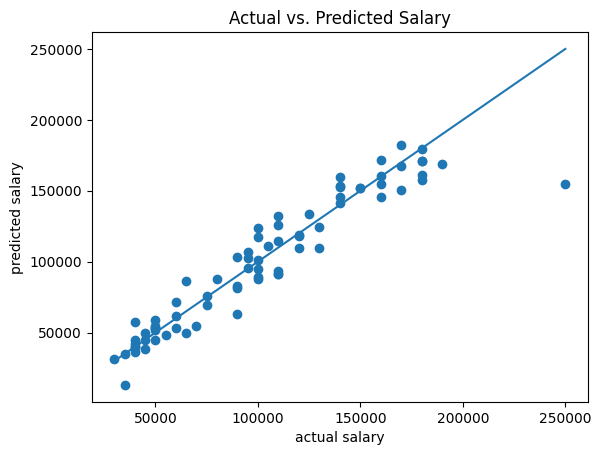

In [63]:
plt.plot(
    [y_test.min(), y_test.max()],   # X
    [y_test.min(), y_test.max()]    # Y
)
plt.scatter(y_test , y_pred)
plt.title("Actual vs. Predicted Salary")
plt.xlabel("actual salary")
plt.ylabel("predicted salary")

## Model Evaluation

The Linear Regression model was evaluated using Mean Absolute Error (MAE) and R² score.

- **MAE:** 10,363.62  
  This means that the model's salary predictions differ from the actual salaries by about 10,364 on average.

- **R² Score:** 0.893  
  This indicates that the model explains approximately 89.3% of the variation in salary in the test data.

The Actual vs. Predicted Salary plot shows that most predictions are relatively close to the ideal prediction line. However, the model has larger errors for some very high salaries.

## Limitations

The Job Level feature was created from job titles using simple keyword-based rules. Therefore, some executive positions such as CEO, VP, and Chief-level roles were categorized as "Other".

This simplified categorization may cause the model to lose important information about job seniority and may contribute to larger prediction errors for some high-salary positions.

## Conclusion

In this project, salary data was cleaned, explored, visualized, and used to build a Linear Regression model for salary prediction.

The analysis showed a strong positive relationship between years of experience and salary. Salary distributions also varied across different job levels.

The Linear Regression model achieved an R² score of 0.893 and a Mean Absolute Error (MAE) of approximately 10,364 on the test data. Overall, the model captured the general salary pattern well, although larger prediction errors were observed for some high-salary positions.

Future improvements could include a more detailed classification of job titles and testing additional regression models.